```GPU - A100 세팅```

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
%cd /content/drive/MyDrive/04. 딥러닝 수업 자료/01. Deep Learning 기초_응용/3. 언어지능

In [ ]:
!pip -q install transformers[torch] datasets

# transformers[torch] : transformers + PyTorch 백엔드를 사용하는 모델을 위한 추가 패키지 설치
# Hugging Face의 'datasets' : 다양한 공개 데이터셋을 쉽게 불러오고 사용할 수 있게 해주는 라이브러리

## 목표
- 사전학습이 되어있는 모델들만 활용하여 `요약 → 임베딩 → 클러스터링 → 감성분석`을 포함하는 통합 분석 파이프라인 구현

## 시나리오

### 배경
- “K-인사이트”는 <u>월간 **50만 건** 이상의 SNS 대화를 처리하는 기업용 분석 플랫폼</u>  
- AI Hub의 한국어 SNS 데이터(“미용과건강”, “식음료”, “일과직업”) 기반으로 사용자의 대화 내용을 <u>자동 탐지·분류</u>해야 함  
- 긴 대화 로그에는 <u>메타정보·반복 발화·잡음</u>이 포함되어 있어, <u>핵심 주제 파악</u>과 <u>감성 분석</u>이 어려움  
- <u>요약 → 임베딩 → 클러스터링 → 감성분석</u>의 통합 파이프라인으로 <u>자동 인사이트 생성</u>이 필요  

```python
# 주요 이해관계자
- 데이터 사이언스팀 : 통합 분석 파이프라인 개발·유지보수  
- 제품 기획팀       : 사용자 인사이트 기반 서비스 기획  
- 운영팀           : 실시간 토픽·감성 모니터링 시스템 운영  
- 마케팅팀         : 토픽별 감성 결과로 캠페인 전략 수립  
```

> AI Hub - 한국어 SNS 데이터셋 링크
> - https://aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=realm&dataSetSn=114
> - JSON 형식으로 제공되며, 각 대화에 메타정보와 발화(utterance) 리스트(body)가 포함
> - 실습상 데이터셋이 방대하여, 실습상 `미용과건강`, `식음료`, `일과직업` 만 활용
>    - 기존 라벨 : 개인관계, 미용과건강, 상거래(쇼핑), 시사교육, 식음료, 여가생활, 일과직업, 주거와 생활, 행사

```python
# unzip 명령으로 압축 해제 (-d : 경로 및 폴더명 지정)
!unzip -q ./data/Korean\ SNS.zip -d ./data/Korean_SNS
```

## 1. 데이터 준비

In [ ]:
import os, json, re

In [ ]:
train_dir = "./data/Korean_SNS/Training/"
val_dir = "./data/Korean_SNS/Validation/"

# train set 353979, val set 44249 로 실습하기엔 너무 많아서 각 라벨별 200개씩만 활용하기 위함
limit_per_label = 200

- 전체 JSON(JavaScript Object Notation) 데이터 로드 전, 샘플로 하나 불러와보기

In [ ]:
# 샘플로 사용할 파일 하나 선택
sample_fname = os.listdir(train_dir)[0]
sample_path  = os.path.join(train_dir, sample_fname)
sample_path

In [ ]:
# JSON 파일 로드 - 1분소요
with open(sample_path, "r", encoding = "utf-8") as f:
    dataset = json.load(f)

dataset.keys()

In [ ]:
# 첫 번째 대화(dialog) 선택
sample_dialog = dataset["data"][0]
sample_dialog

In [ ]:
# 텍스트 지정
sample_dialog['body'][3]["utterance"] # utterance(어더랜스) : 발화, 언어학과 언어 철학에서 대다수 현대적 분석의 기본 언어 단위

In [ ]:
# 모든 발화(utterance)를 공백으로 연결하여 텍스트 생성
sample_text = " ".join(turn["utterance"] for turn in sample_dialog["body"])
print(sample_text)

In [ ]:
from tqdm.auto import tqdm

In [ ]:
# 모든 JSON 데이터 로드 함수 정의

def load_and_normalize(dir_path):
    """
    지정한 디렉토리(dir_path) 내 모든 JSON 파일을 순회하며,
    각 대화(dialog)의 'body' 필드에 담긴 발화(utterance)를 하나의 문서(text)로 연결한 뒤
    리스트로 반환하는 함수

    인자(dir_path) : JSON 파일들이 들어 있는 폴더 경로
    반환(corpus) : 대화별로 병합된 텍스트 리스트
      -
    """
    corpus = []  # 결과를 담을 빈 리스트

    # 해당 폴더 내 모든 파일 이름을 가져와서 반복
    for fname in tqdm(os.listdir(dir_path), desc=f"Loading {dir_path}"):
        file_path = os.path.join(dir_path, fname)  # 각 파일의 전체 경로 생성
        count = 0                                  # 라벨당 문서 수 카운터 초기화

        # JSON 파일 로드
        with open(file_path, "r", encoding="utf-8") as f:
            dataset = json.load(f)  # JSON 구조: {"numberOfItems":..., "data":[{dialog1}, ...]}

        # 'data' 배열 안의 각 대화(dialog)를 순회
        for dialog in tqdm(dataset["data"], desc=f"Preprocessing {fname}") :

            # 라벨당 제한(limit_per_label) 초과 시 반복 종료
            if count >= limit_per_label:
                break

            # 각 발화(turn)의 'utterance' 필드만 추출하여 공백으로 연결
            # 결과적으로 한 대화의 모든 발화가 하나의 긴 문자열로 합쳐짐
            text = " ".join(turn["utterance"] for turn in dialog["body"])

            corpus.append(text)  # 리스트에 추가
            count += 1                  # 문서 카운터 증가

    return corpus

In [ ]:
# 학습 및 검증 데이터셋 로드 - 약 1분 소요
train_corpus = load_and_normalize(train_dir)
val_corpus = load_and_normalize(val_dir)

In [ ]:
# 불러온 데이터 수 및 샘플 출력
print(f">>> Train 문서 수: {len(train_corpus)}")  # 학습 데이터 문서 총 개수
print(f">>> Val   문서 수: {len(val_corpus)}")    # 검증 데이터 문서 총 개수
print(">>> 샘플 문서 3개:")
for i in range(3):
    # 앞 100자만 출력하여 길이 과다 방지
    print(f"[문서 {i+1}] {train_corpus[i][:100]}...\n")

## 2. 대화 요약 (Summarization)
- 문서 길이 절감 : 요약을 통해 핵심 내용만 남기면 후속 임베딩·토픽 모델링 연산 속도를 높일 수 있음
- 노이즈 제거: 불필요한 대화(인사, 중복 발화 등)를 압축하여 중요한 주제어 비중을 높임
- 토픽 명확화: 긴 대화 대신 요약문을 사용하면 BERTopic이 더 뚜렷한 주제어를 학습 가능

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# AutoTokenizer: 다양한 사전학습 토크나이저를 쉽게 로드
# AutoModelForSeq2SeqLM: Seq2Seq(입력→출력) 구조의 언어모델(요약, 번역 등)에 사용되는 클래스

### T5?
- 요약 모델(KoT5) 허깅페이스 : https://huggingface.co/psyche/KoT5-summarization
- KoT5: 한국어 T5(Text-to-Text Transfer Transformer) 모델

> #### 사전학습 정보 (Pre-training)
- **코퍼스**  
  - 위키백과, 신문기사 등 23개 출처에서 수집한 총 939 GB 원시 데이터 → 전처리 후 약 42 GB 말뭉치 사용
- **체크포인트**  
  - KoT5-Small: 6 layers, hidden_size=512, 60M 파라미터  
  - KoT5-Base: 12 layers, hidden_size=768, 220M 파라미터

> #### 파인튜닝(Fine-tuning)
- **데이터셋**  
  - AI-Hub “도서자료 요약” 데이터셋  
- **디코딩 설정**  
  - greedy decoding  
  - 최대 길이 `max_length=256`, `repetition_penalty=2.0` 적용
  - repetition_penalty : 같은 토큰이 반복적으로 나오면 penalty를 적용해서 해당 토큰의 logit을 낮춰줌 (값은 1.0 이상이며, 값이 클 수록 penalty를 세게 적용)

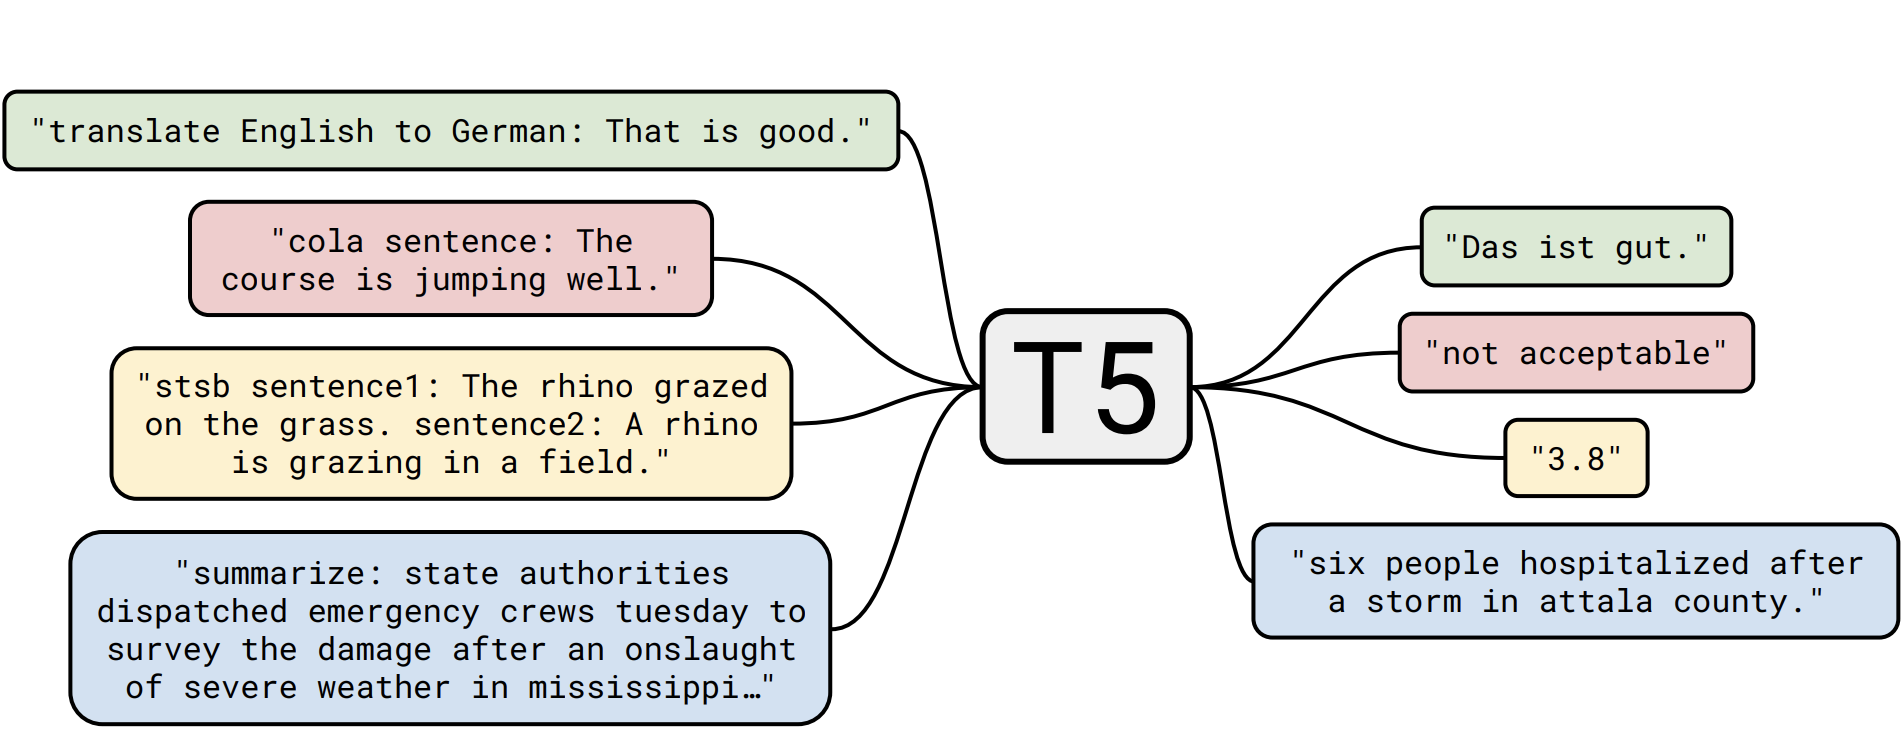

- T5 Architecture

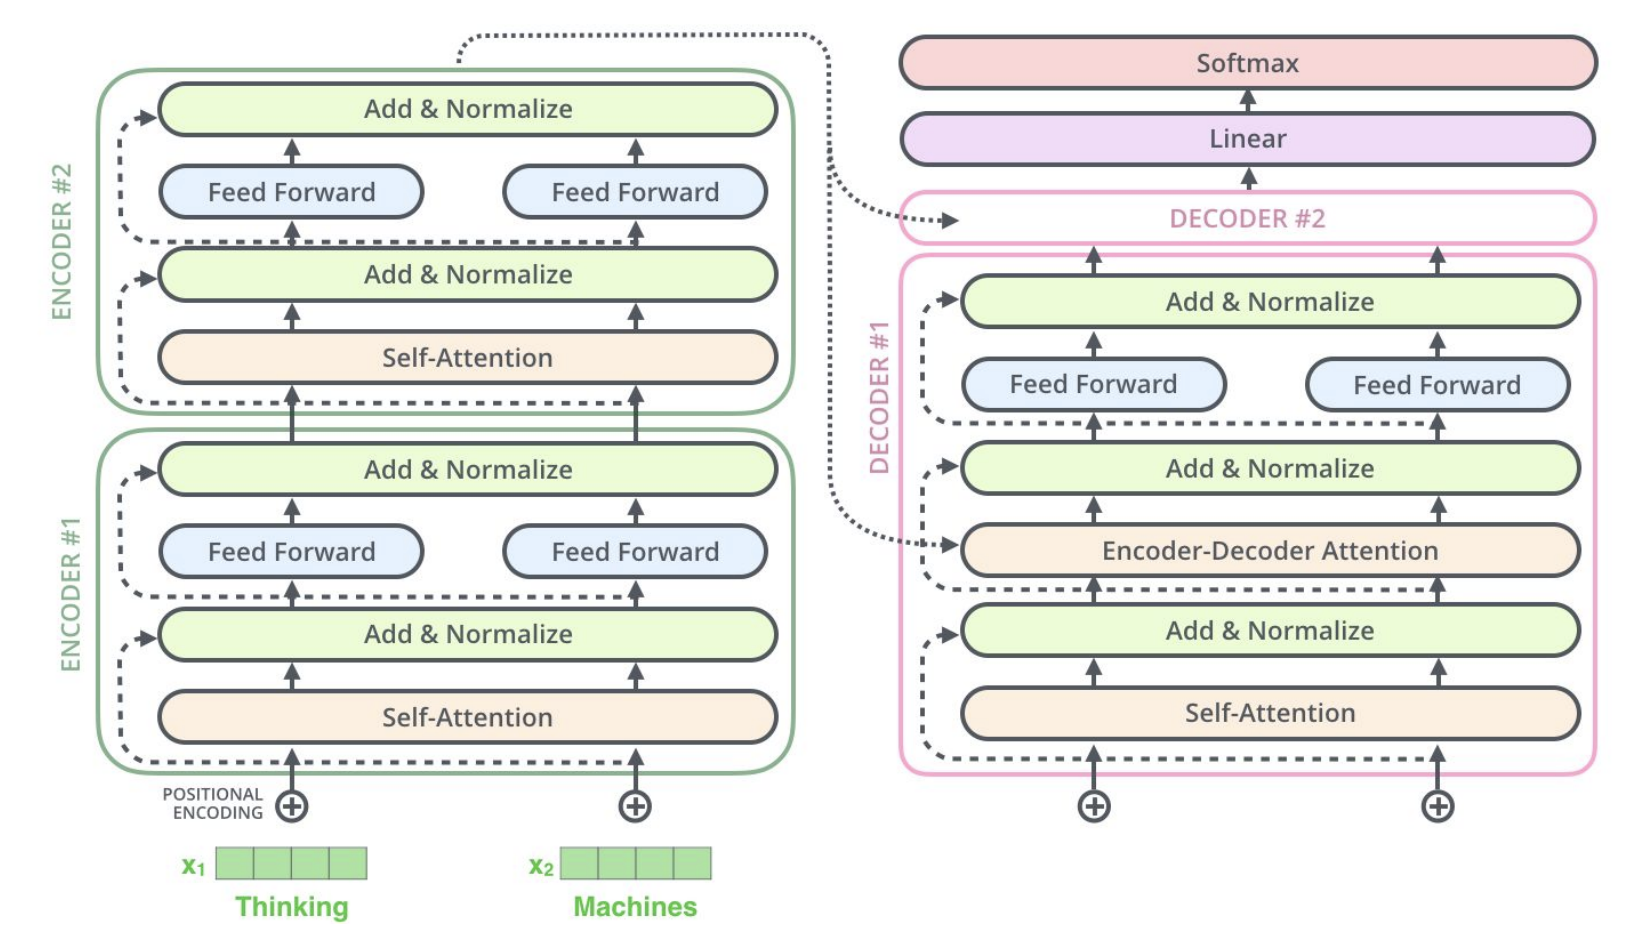

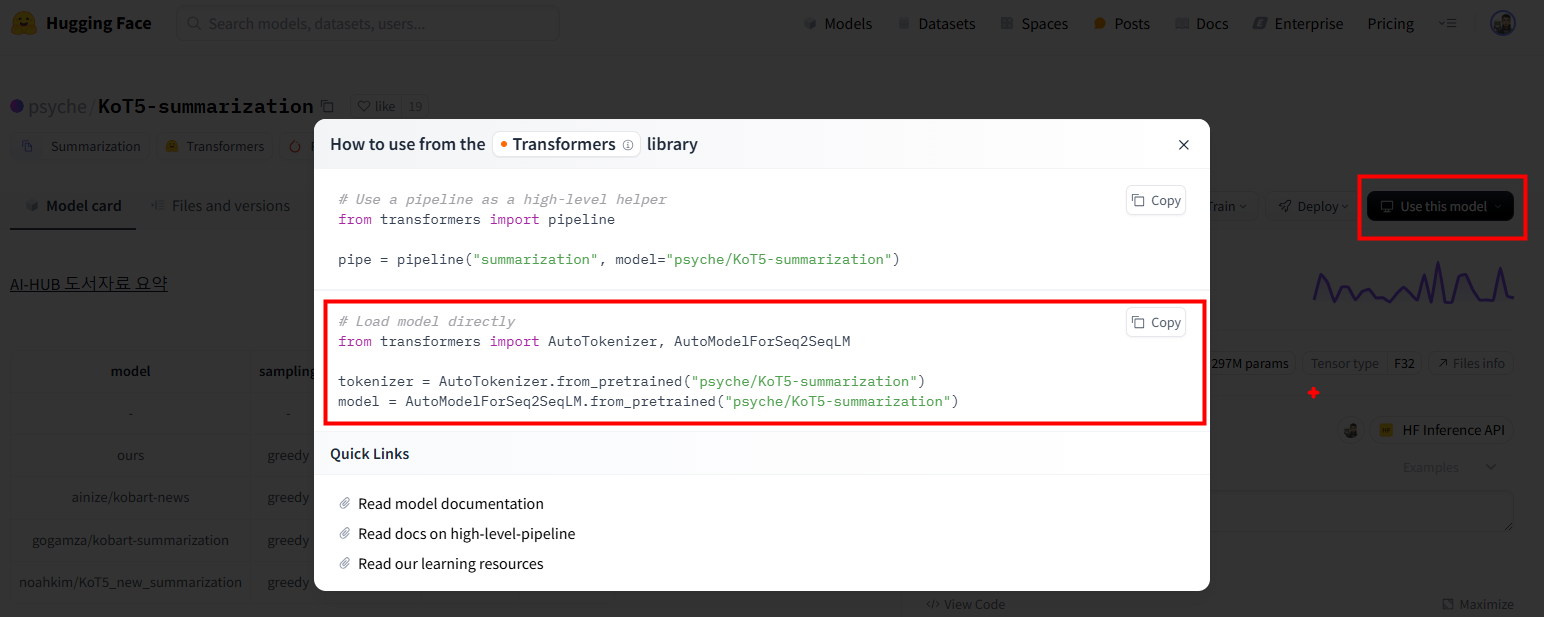

In [ ]:
# 사전 학습 된 한국어 요약 모델(KoT5)명
model_name = "psyche/KoT5-summarization"

In [ ]:
# 요약 모델 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
# 지정 된 디바이스 확인 (GPU 사용 여부 확인)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

In [ ]:
# 요약 모델 로드
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda")
# .to("cuda") : 지정된 디바이스(일반적으로 GPU)로 텐서를 이동

- 샘플 텍스트로 요약 모델 테스트

In [ ]:
# 샘플 텍스트 준비
sample_text = train_corpus[0]
print(sample_text)

In [ ]:
# 입력 텍스트 토큰화 및 디바이스 이동
inputs = tokenizer(
    sample_text,           # 요약 대상 텍스트
    return_tensors = "pt", # PyTorch 텐서로 반환
    truncation = True,     # 길이 초과 시 잘라내기
    max_length = 512       # 토큰 길이 제한 (T5 Position embedding 크기가 512로 고정)
).to(device)               # 지정된 디바이스(일반적으로 GPU)로 텐서를 이동
inputs

# 'input_ids' : 토큰 ID (주어진 문장을 모델이 이해할 수 있는 정수 ID 시퀀스로 변환한 결과)
# 'attention_mask': 패딩된 토큰(padding)과 실제 토큰을 구분하는 마스크 (1은 실제 토큰, 0은 패딩 토큰을 나타냄)

In [ ]:
# 요약 시퀀스 생성
outputs = model.generate(
    **inputs,              # tokenizer가 반환한 딕셔너리(**inputs) 형태로 전달
    max_length = 100,      # 요약문의 최대 토큰 길이
    min_length = 20,       # 요약문의 최소 토큰 길이
    num_beams = 4,         # 빔 서치 수 : 매 단계마다 가장 가능성 높은 4개 후보를 유지하며 탐색
                           # Beam Search : 단일 최적 경로만 보는 그리디 탐색과 달리, 여러 후보를 동시에 고려해 더 나은 전체 시퀀스를 찾음

    early_stopping = True, # 조기 종료 여부 : EOS 토큰(문장 끝 표시)을 만나면 즉시 생성 멈춤
                           # 불필요한 패딩(token_id = pad) 또는 중복 생성 방지

    length_penalty = 2.0   # 길이 패널티 : 생성 길이에 가중치를 주어 스코어 조정
                           # 값 > 1.0 : 긴 시퀀스일수록 페널티 커져 짧은 출력을 선호
                           # 값 < 1.0 : 긴 시퀀스에 대한 페널티 작아져 긴 출력을 유도
)

outputs

In [ ]:
# 토큰 시퀀스를 텍스트로 디코딩
summary = tokenizer.decode(
    outputs[0],                # 생성된 토큰 ID 목록 (첫 번째 문장)
    skip_special_tokens = True # <pad>, <eos> 등의 특수 토큰 제거
)

summary

In [ ]:
# 텍스트 요약 함수 정의
def summarize(text):
    """
    입력 텍스트를 KoT5로 요약하는 함수
    """

    # 1) 입력 토큰화 및 GPU 이동
    inputs = tokenizer(
        text,
        return_tensors = "pt",
        truncation = True,     # 입력 문장이 너무 길 경우 자름
        max_length = 512       # KoT5가 처리할 수 있는 최대 입력 토큰 길이
    ).to("cuda")

    # 2) 요약문 생성
    outputs = model.generate(
        **inputs,
        max_length = 100,      # 생성할 요약문 최대 길이
        min_length = 20,       # 최소 생성 길이
        num_beams = 4,         # 빔 서치 개수 (다양한 후보 생성 후 최적 선택)
        early_stopping = True, # EOS 토큰 도달 시 조기 종료
        length_penalty = 2.0   # 요약 길이에 대한 패널티
    )

    # 3) 디코딩 및 반환
    summary = tokenizer.decode(outputs[0], skip_special_tokens=True) # <pad>, <eos> 등 특수 토큰 제거
    return summary

In [ ]:
# 실습 상 Train set만 활용
# Train 샘플 요약 - A100 약 12분 소요
summaries = [ summarize(doc) for doc in tqdm(train_corpus, desc="Summarizing") ]

In [ ]:
print("\n=== 요약 결과 샘플 ===")
for i in range(3):
    print(f"[원문{i}]", train_corpus[i])
    print(f"[요약{i}]", summaries[i], "\n")

## 3. 임베딩 모델 선택
- 텍스트를 수치 벡터(임베딩)로 변환해야 **<U>유사도**</U> 계산이나, **<U>클러스터링**</U>이 가능

> #### **<U>SBERT(Sentence-BERT)**</U> 활용
> - BERT 모델을 **<U>문장 임베딩(`Sentence Embedding`)을 생성하는 모델**</U>로 활용할 수 있도록 Fine-tuning하는 방법(또는 모델명) 을 의미
> - **<U>문장 간 의미적 관계를 잘 보존하는 임베딩을 제공**</U>

- `Sentence embedding` : 문장 정보를 벡터 공간의 위치로 표현한 값
- 문장을 벡터 공간에 배치함으로서 **<U>문장 간 비교, 클러스터링, 시각화 등 다양한 분석 기법**</U>을 이용할 수 있는 것이 장점

In [ ]:
from sentence_transformers import SentenceTransformer  # SBERT 임베딩 모델 로드용

# Colab에는 기본 내장 되어있음
# 필요 시 SBERT 모델 사용을 위한 패키지 설치
# !pip -q install sentence-transformers

### 한국어 특화 Sentence-BERT (SBERT)
- 사용 모델 허깅페이스 : https://huggingface.co/snunlp/KR-SBERT-V40K-klueNLI-augSTS
- 문장·단락을 768차원 밀집 벡터로 변환해 클러스터링, 의미 검색 등에 활용 가능

> #### 사전학습 정보 (Pre-trained BERT)
> - **<U>KR-BERT-V40K**</U> :  WordPiece 토크나이저 (어휘 사전 크기 40K)  
> - 문장 내 토큰별 Contextualized 벡터(`컨텍스츄얼라이즈드`, 상황에 맞는)를 `Average Pooling`으로 문장 벡터 생성
> - SBERT의 `Average Pooling` : 문장 전체 토큰의 맥락을 고르게 반영하여 **<U>한 개의 벡터로 만드는 과정**</U>

> #### 파인튜닝 (Fine-tuning)
> - **<U>Siamese 네트워크 구조**</U>
>    1. 두 문장 벡터를 분류기(Classifier)에 입력  
>    2. 문장 간 관계 반영하도록 BERT 가중치 파인튜닝
>    - 임베딩 공간 자체가 "유사한 것끼리 모이고, 다른 것은 멀어지도록" 학습되려면, 문장 쌍을 동시에 보고 비교하는 Siamese 구조가 필요함  
> - **<U>학습 데이터**</U>  
>    - KLUE-NLI (한국어 자연어 추론)  
>    - KorSTS(한국어 STS) 데이터셋을 in-domain 전략으로 증강

#### Siames Neural Network(샴 네트워크)의 구조

> **구조 개요**
> - 왼쪽에 서로 다른 두 입력(예: 두 이미지, 두 문장)이 들어감
> - 중앙의 네트워크 블록(회색 박스)은 **동일한 가중치**를 공유하며(Weight Sharing) 두 입력을 각각 처리
> - 오른쪽에서 각 입력으로부터 나온 **임베딩 벡터**(Embedding 1, Embedding 2)를 비교하여 거리를 계산(Distance)
> - 마지막으로 "두 입력이 같은 클래스인가?"를 확률(Probability)로 출력

> **세부 동작 흐름**
> 1. **Input 1 / Input 2**
>    - 비교·판단할 대상 데이터
> 2. **Siamese subnetwork**
>    - 두 입력에 **같은** 모델(같은 구조, 같은 가중치) 적용
>    - 입력마다 별도로 통과시키지만, 학습 시 가중치는 공유
> 3. **Embedding 1 / Embedding 2**
>    - 각 서브넷워크의 마지막 레이어에서 추출된 고차원 특징 벡터(예: 128차원, 768차원)
> 4. **Distance 계산**
>    - 두 임베딩 벡터 간 유클리드 거리(Euclidean)나 코사인 유사도(Cosine) 등으로 계산
>    - 거리가 짧으면 "비슷하다" → 같은 클래스 확률↑, 거리가 멀면 "다르다" → 확률↓
> 5. **Probability 출력**
>    - 거리를 바탕으로 이진 분류기(혹은 유사도 점수)로 맵핑
>    - "같은 클래스일 확률"을 0\~1 사이 값으로 반환

- 결론적으로 모든 학습 데이터에 대한 임베딩 값을 Scattering 했을 때, 같은 클래스끼리는 모이고 다른 클래스끼리는 멀어지는 결과를 보여줌

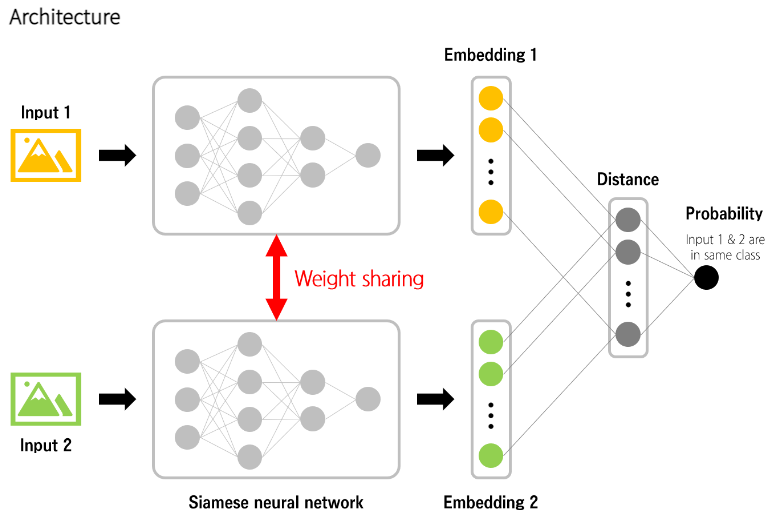

In [ ]:
embedding_model = SentenceTransformer("snunlp/KR-SBERT-V40K-klueNLI-augSTS")

## 4. 토픽 모델링 (BERTopic 적용)
- 4.1 원문 기반 토픽 모델링 수행
- 4.2 요약문 기반 토픽 모델링 수행
- 문서 집합 내에서 **<U>숨겨진 주제나 토픽을 찾아내는 텍스트 마이닝 기법**</U>
- 기계 학습 및 자연어 처리 분야에서 널리 사용되며, 문서들을 분석하여 어떤 주제들이 포함되어 있는지, 각 문서가 어떤 주제와 연관되어 있는지를 파악하는 데 활용

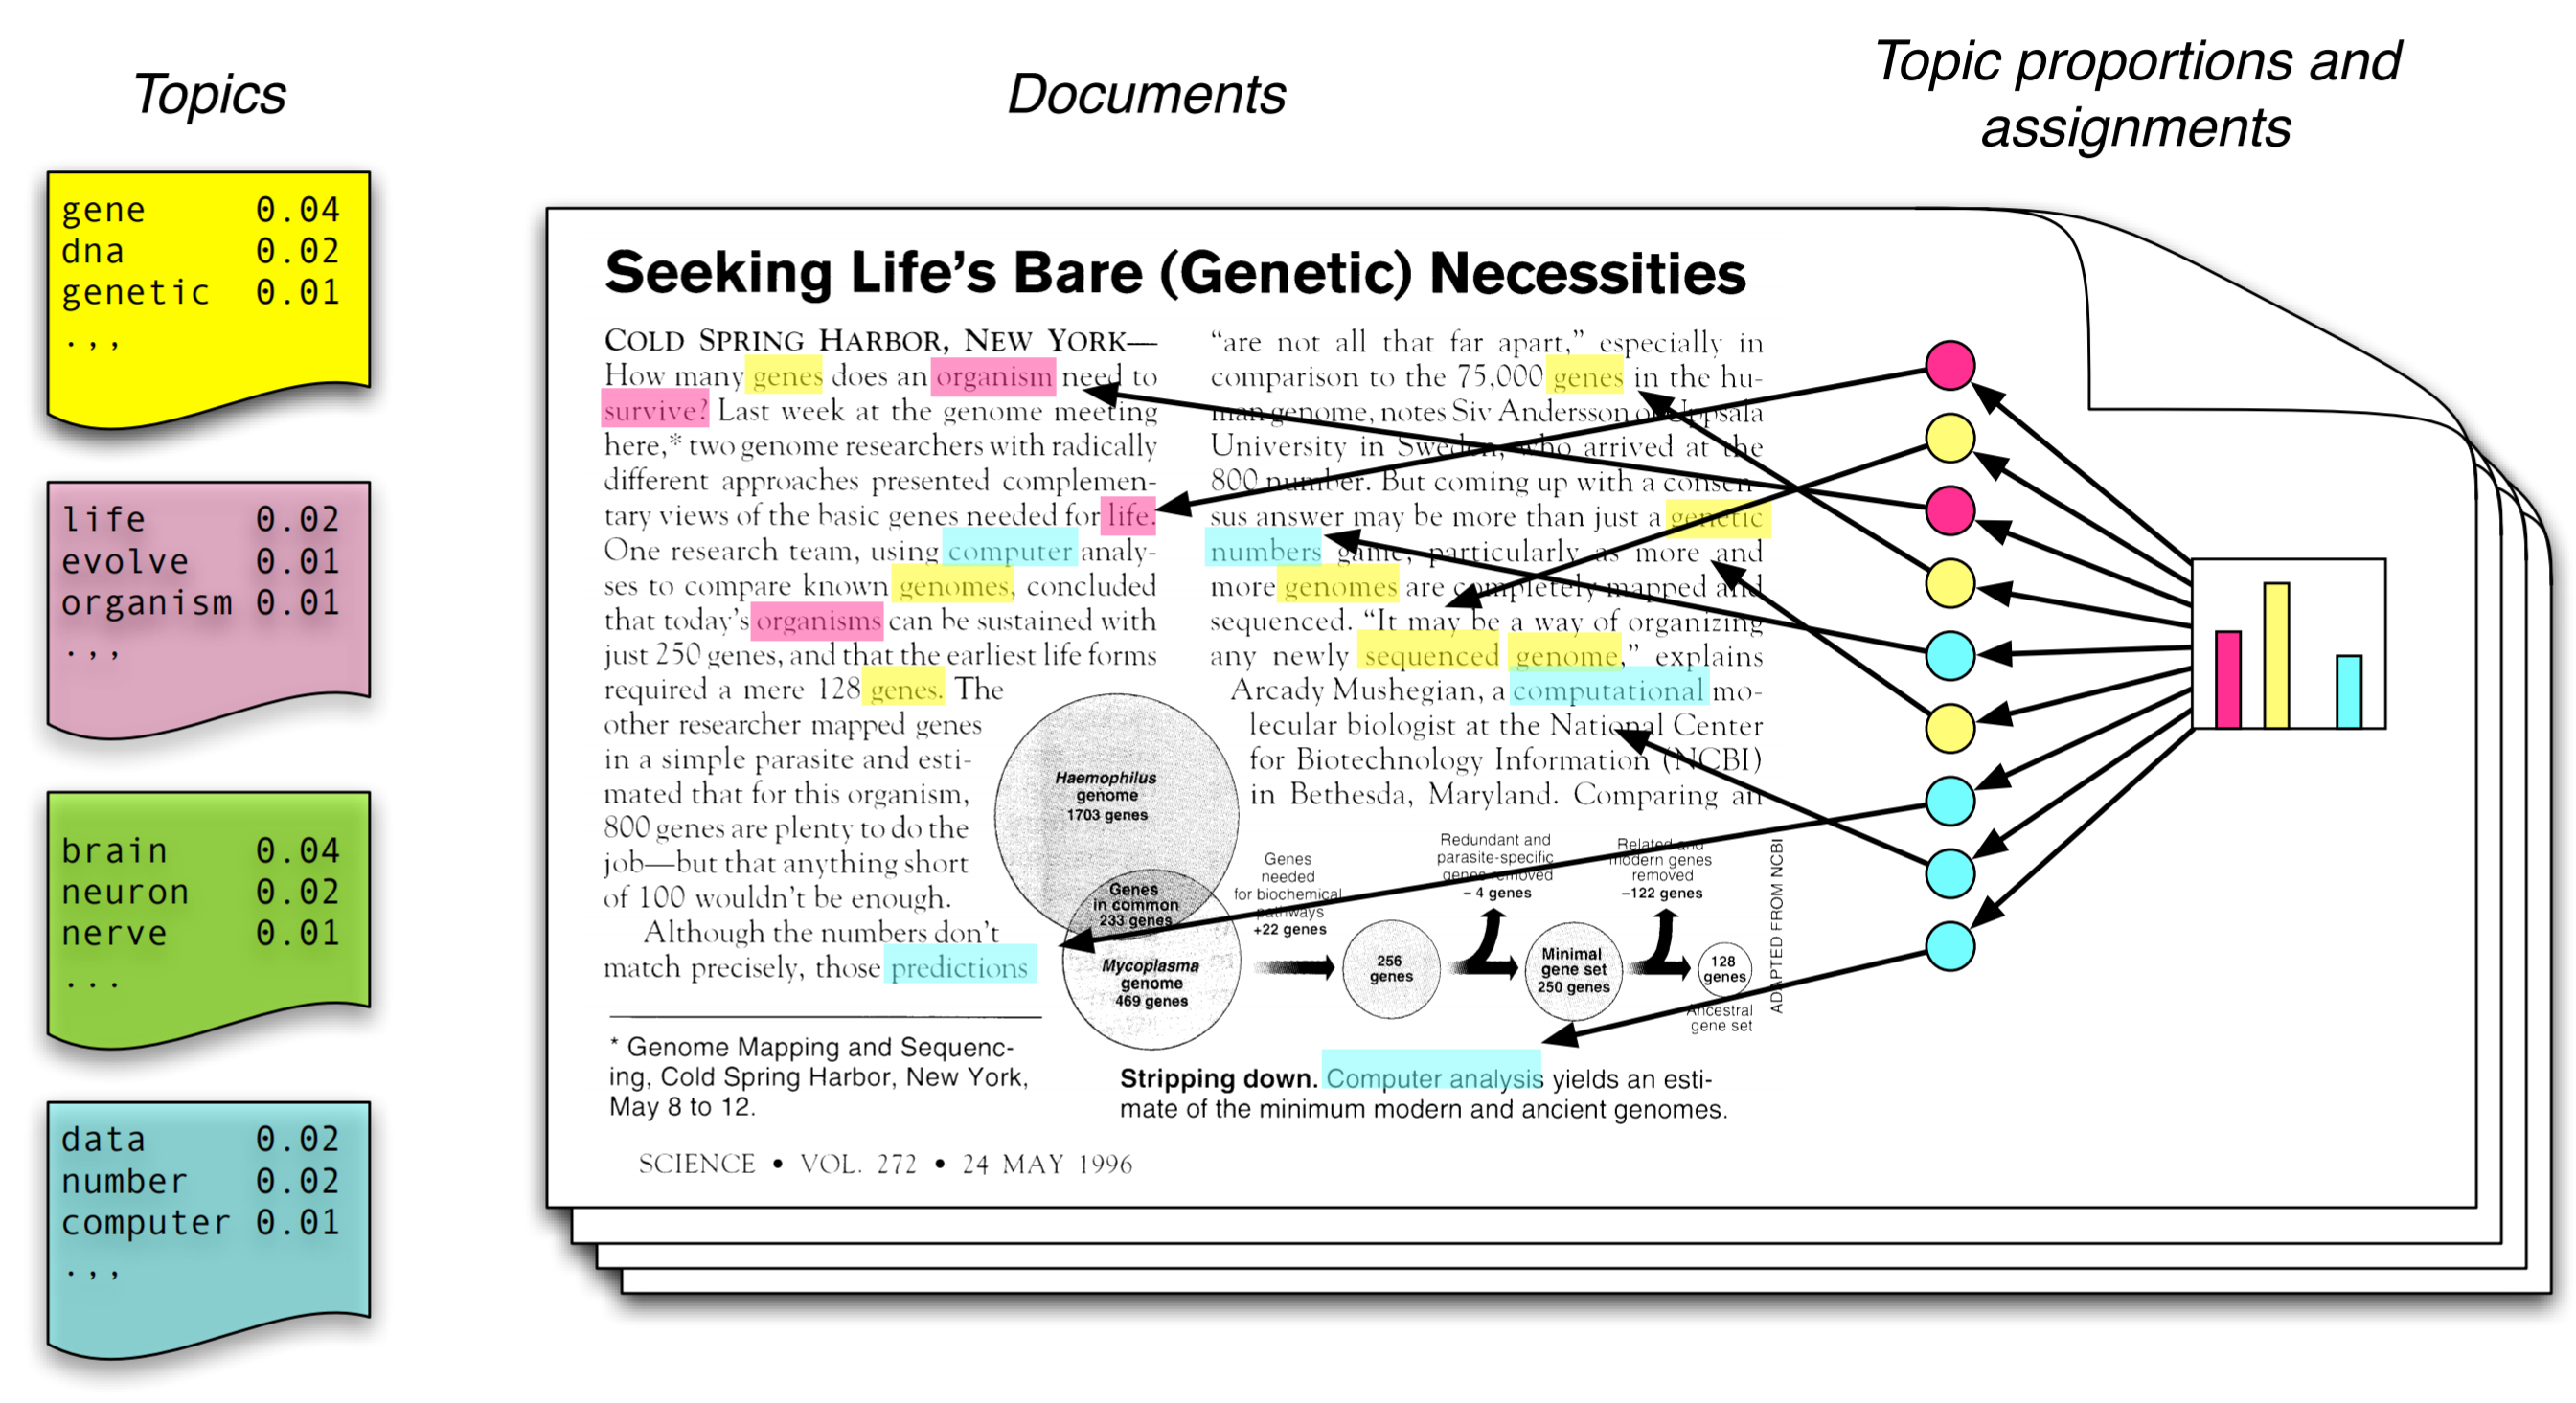

#### BERTopic
- Transformer 기반 임베딩(BERT 등)과 군집화 기법(HDBSCAN)을 결합한 토픽 모델링 기법
- 임베딩된 문서를 UMAP으로 차원 축소 후, HDBSCAN(또는 KMeans)으로 클러스터링 수행
- 각 클러스터의 대표 키워드를 추출하여 토픽을 해석하기 용이하게 함
- 전통적 LDA처럼 단어 빈도만 보는 게 아니라, 문장·문서 간 의미적 유사성을 반영

> LDA (Latent Dirichlet Allocation)
> - 자연어 처리에서 문서에 내재된 주제를 파악하는 확률적 토픽 모델링 기법
> - 빈도수만을 활용하며, Topic의 개수를 Coherence(주제 일관성) & Perplexity(혼란도) 등을 활용하여 수동 설정 필요

#### BERTopic 주요 구성요소

> ##### 문서 임베딩(Embed Documents)
> - 입력된 문서(문장, 단락 등)를 BERT 계열 모델로 768차원 이상의 실수 벡터로 변환
> - 의미론적 유사성을 벡터 간 거리로 표현할 수 있도록 함

> ##### 차원 축소 (UMAP, Uniform Manifold Approximation and Projection)
> - 고차원(768차원)의 임베딩을 2~5차원 정도로 줄여 계산·시각화 효율 개선
> - 유사한 벡터는 가깝게, 먼 벡터는 멀게 배치
> - 차원 축소 알고리즘 중 하나 (가장 좋은 성능을 내는 알고리즘이라고 알려짐, https://towardsdatascience.com/topic-modeling-with-bert-779f7db187e6)

> ##### 밀도 기반 군집화 (HDBSCAN, Hierarchical Density-Based Spatial Clustering of Applications with Noise)
> - DBSCAN의 단점을 보완해 **계층적(hierarchical)** 구조로 확장
> - UMAP으로 축소된 벡터 공간에서 “문서 간 밀도 차이”를 이용해 클러스터(토픽) 자동 판단
> - 노이즈(어느 클러스터에도 속하지 않는 문서)도 함께 걸러냄

> ##### 토픽 키워드 생성(c-TF-IDF, class-based TF-IDF)
> - document들로 클러스터링 된 군집들에 대하여 TF-IDF의 개념을 적용하기 위해 변형된 형태
> - 클러스터별로 속한 문서들을 하나의 가상 문서(corpus)로 보고
> - 그 내부에서 TF-IDF를 계산해 “해당 토픽을 대표할 키워드” 추출

> ##### 결과 정제(MMR, 선택적)
> - 키워드 후보 중 중복을 줄이고 다양성을 높이기 위해 MMR(Maximal Marginal Relevance) 적용
> - 중요 키워드를 균형 있게 선별

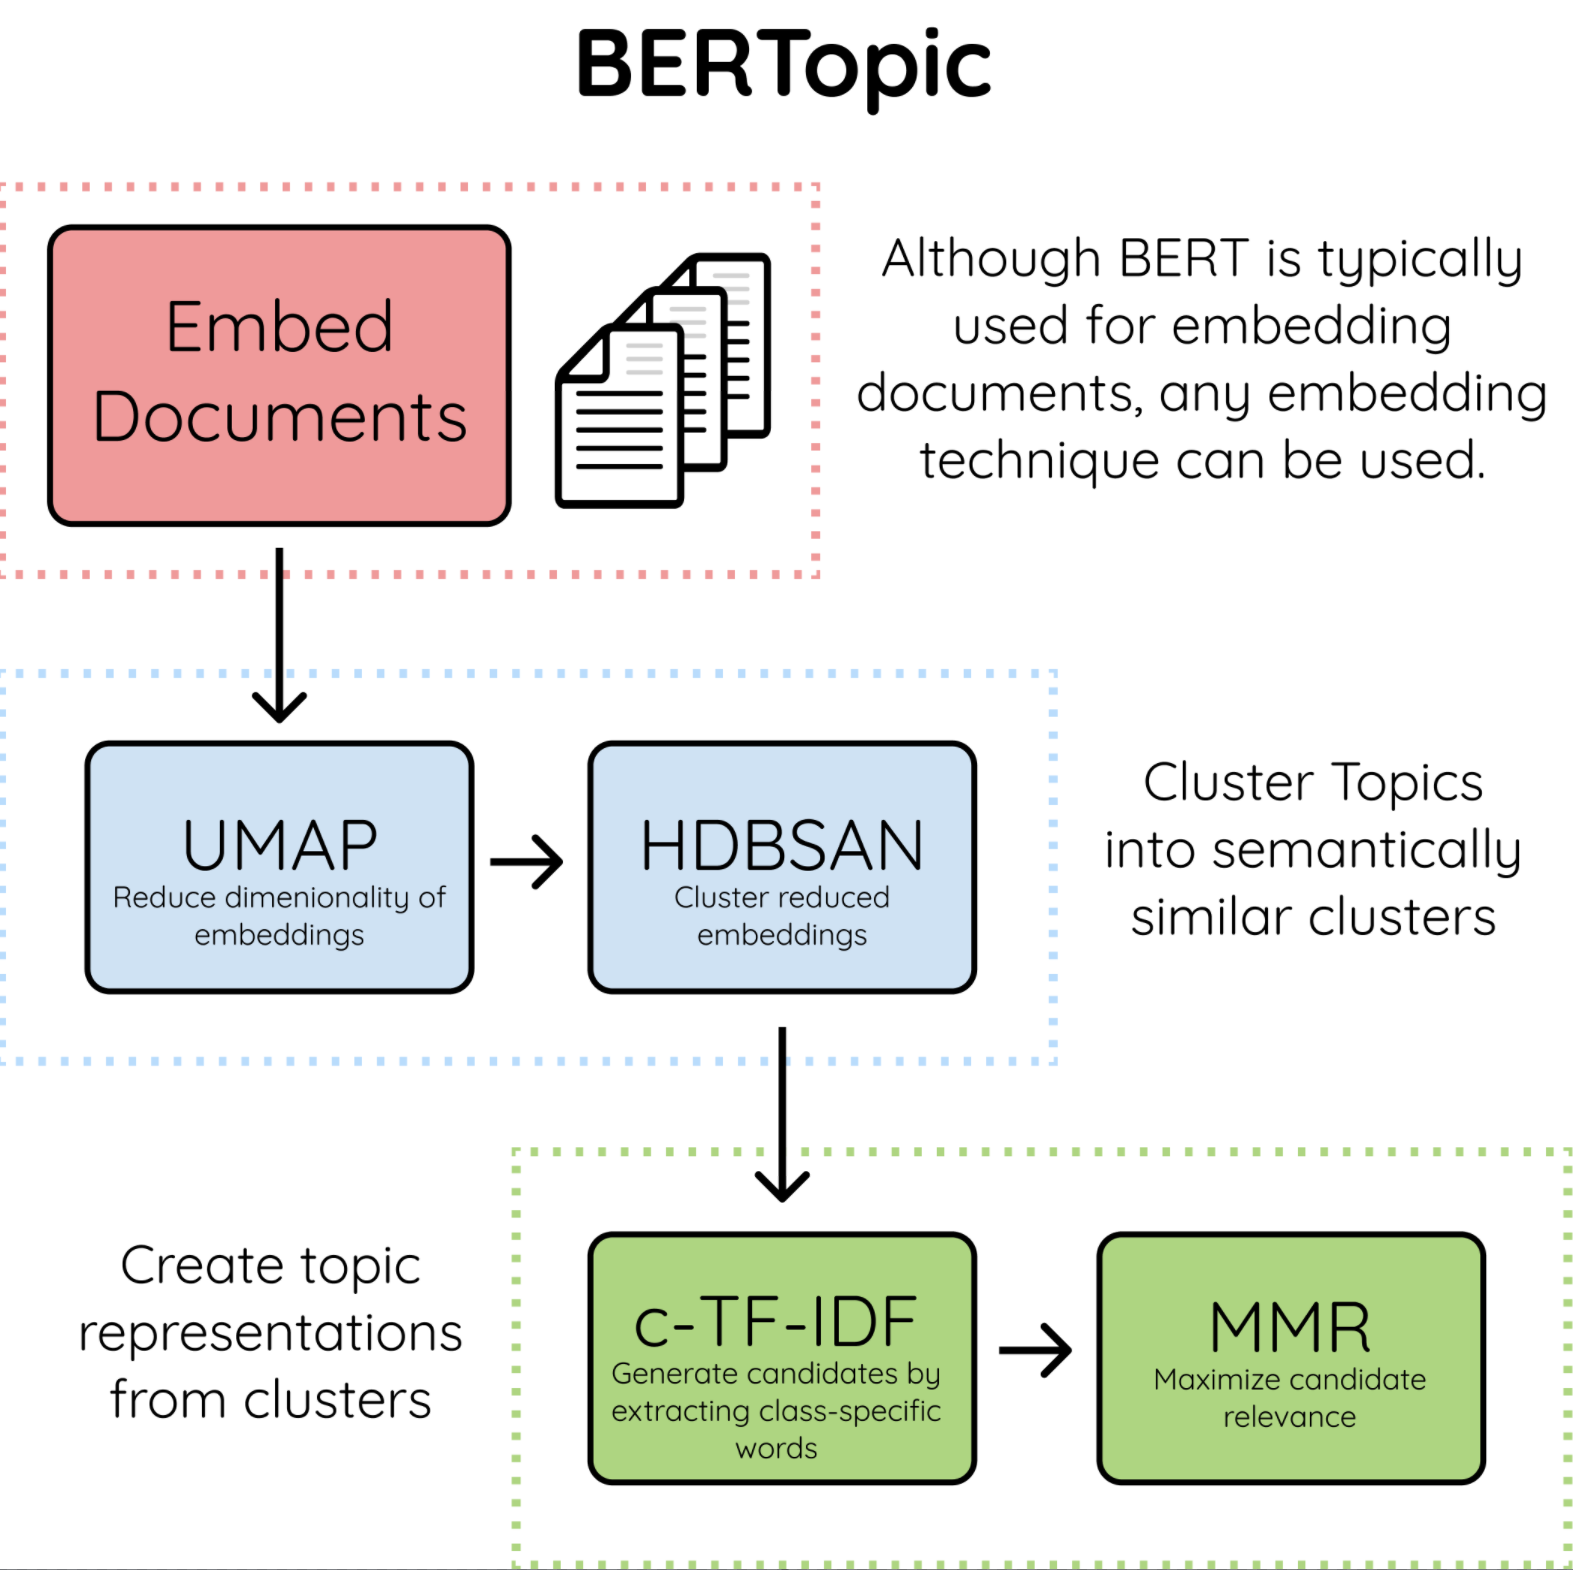

> ##### 장점
> - 의미 기반 토픽 추출: 단순 단어 빈도만 보는 LDA 대비 더 정교
> - 토픽 수 자동 결정 및 노이즈 필터링
> - 시각화(2D scatter, 토픽 분포 차트) 기능 내장
> - 다양한 언어·도메인에 손쉽게 적용 가능

> ##### 단점 및 주의사항
> - 파라미터 민감도: UMAP(n_neighbors, min_dist), HDBSCAN(min_cluster_size) 튜닝 필요
> - 대규모 데이터에서 메모리·시간 부담 있을 수 있음
> - 사전학습 임베딩 모델 선택에 따라 성능 차이

- 요약 전(orig)·후(sum) 결과 차이를 직접 비교

In [ ]:
!pip -q install --upgrade bertopic

# bertopic : BERTopic 패키지 ( + 시각화에 필요한 의존성(Plotly 등)이 기본 설치 됨)
# --upgrade : 최신본 설치

In [ ]:
from bertopic import BERTopic # BERTopic 토픽 모델링 클래스

- 4.1 원문 기반 토픽 모델링 수행

In [ ]:
# 원문(original) 기반 BERTopic 초기화
topic_model_orig = BERTopic(
    embedding_model = embedding_model, # SBERT 임베딩 모델 객체
    calculate_probabilities = True,    # 문서별 토픽 확률을 계산
    verbose = True                     # 학습 중 상세 로그 출력
)

In [ ]:
# 원문에 대해 토픽 모델링 수행
topics_orig, probs_orig = topic_model_orig.fit_transform(train_corpus)

In [ ]:
print(topics_orig) # 문서별 할당된 토픽 번호 (토픽 –1 : Noise)
print(probs_orig)  # 문서가 토픽 n에 속할 확률 (토픽 –1은 두 열의 합이 1보다 작다면 나머지 확률만큼 노이즈일 가능성이 있다는 뜻)

In [ ]:
# 토픽 정보 확인
info_orig = topic_model_orig.get_topic_info()
info_orig

# Topic : 토픽 ID
# Count : 해당 토픽에 할당된 문서(대화) 개수
# Name : <토픽 번호>_<대표 키워드 조합>  →  토픽 번호와 해당 토픽을 대표하는 키워드 일부 결합
# Representation : c-TF-IDF로 추출한 "토픽별 상위 키워드" 리스트
# Representative_Docs : 해당 토픽을 대표하는 문서(대화) 샘플 리스트

In [ ]:
# 전체 문서 개수 조회
info_orig['Count'].sum()

- 4.2 요약문 기반 토픽 모델링 수행

In [ ]:
# 요약(summaries) 기반 BERTopic 초기화
topic_model_sum = BERTopic(
    embedding_model = embedding_model,
    calculate_probabilities = True,
    verbose = True
)

In [ ]:
# 요약문에 대해 토픽 모델링 수행
topics_sum, probs_sum = topic_model_sum.fit_transform(summaries)

In [ ]:
# 토픽 정보 확인
info_sum = topic_model_sum.get_topic_info()
info_sum

# 요약 기반에서는 조금 더 정제 되어 토픽 해석이 보다 직관적임
# 특히 중복되는 불용어("이름", "시스템" 등)가 줄어든 것이 특징

In [ ]:
# 0번 토픽별 상위 키워드 리스트
info_sum["Representation"][1]

In [ ]:
# 0번 토픽별 상위 키워드 리스트 + cTFIDF 점수 (높을수록 그 토픽을 잘 대표하는 키워드라는 뜻)
topic_model_sum.get_topic(-1)

In [ ]:
# 원문 토픽별 대표 키워드
for t in info_orig.Topic.unique() :
    if t == -1 : # Noise 토픽 제외
        continue
    print(f"\n[원문 토픽 {t}] 키워드:")
    display(topic_model_orig.get_topic(t))

In [ ]:
# 요약본 토픽별 대표 키워드
for t in info_sum.Topic.unique() :
    if t == -1 : # Noise 토픽 제외
        continue
    print(f"\n[원문 토픽 {t}] 키워드:")
    display(topic_model_sum.get_topic(t))

## 5. 결과 비교 및 시각화

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Seaborn 시각화의 경우, font_manager로 직접 추가해야 한글 시각화 가능

# GULIM.TTC 경로 지정 (./data/GULIM.TTC라면 그대로 사용)
font_path = "./data/GULIM.TTC"
fm.fontManager.addfont(font_path)

# FontProperties를 통해 실제 패밀리 이름 가져오기
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()    # 예: 'Gulim'

# matplotlib 전역 설정에 등록
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

- 5.1 토픽 분포 비교

In [ ]:
# 토픽 비교용 DataFrame 생성
df_topic_compare = pd.DataFrame({
    "original": topics_orig,
    "summary":  topics_sum
})

df_topic_compare

In [ ]:
# 원문 - 토픽별 문서수 집계 - 인덱스(토픽 ID) 기준 정렬
df_topic_compare["original"].value_counts().sort_index()

In [ ]:
# 원문, 요약문 토픽별 문서 수 집계
orig_topic_counts = df_topic_compare["original"].value_counts().sort_index()
summary_topic_counts  = df_topic_compare["summary"].value_counts().sort_index()

# 하나의 DataFrame으로 합치기
df_topic_counts = pd.concat(
    [orig_topic_counts, summary_topic_counts],  # 병합할 두 시리즈
    axis=1,                                      # 열 단위 병합
    keys=["orig_count", "sum_count"]             # 새 DataFrame의 컬럼명 지정
).fillna(0)                                      # NaN 값을 0으로 채움

df_topic_counts

In [ ]:
# 막대그래프
plt.figure(figsize=(10,5))
df_topic_counts.plot(kind="bar", width=0.8)      # bar 차트, 바 너비 0.8
plt.title("원문 vs 요약 토픽별 문서 분포")
plt.xlabel("토픽 ID")
plt.ylabel("문서 수")
plt.xticks(rotation = 0)                   # x축 눈금 레이블 각도 0도로 설정
plt.legend(["Original", "Summary"])        # 범례 이름 설정
plt.show()

### Bar 차트 해석

> **<U>노이즈(-1) 토픽 증가</U>**
> - 요약 과정에서 맥락이 충분치 않은 문서들이 “노이즈”로 분류되는 사례가 늘어났음이 관측됨  
> - 불필요한 대화나 중복 발화가 제거되며, 주제 식별이 어려운 문서가 더 많아진 영향으로 보임

> **<U>토픽 0 감소</U>**
> - 요약 전후 가장 큰 이동이 토픽 0 → 토픽 1 전환(−42)과 토픽 1 증가(+52)  
> - 긴 원문에 분산됐던 핵심 단어들이 요약문에서 토픽 1(예: 특정 감정·행동 패턴)에 집중된 결과로 해석됨  
> - 새로 등장한 토픽 5(+12)도 요약 실험에서만 드러난 새로운 주제군일 수 있음

> **<U>토픽 2·3 축소</U>**
> - 상대적으로 덜 뚜렷했던 토픽 2(−65%)와 토픽 3(−31%)에 속했던 문서들이  
>   요약 후 다른 토픽으로 재배치되거나 노이즈로 분류되었음

> **<U>토픽 응집도 개선 가능성</U>**
> - 요약을 통해 “의미가 분산됐던 문장”들이 핵심 주제로 옮겨가면서, 특정 토픽(예: 1, 5)의 응집도가 높아진 것으로 보임  
> - 반면, 정보가 부족해진 문서는 노이즈로 분류되어 전체 토픽 수는 오히려 다양해졌음

- 5.2 토픽별 대표 키워드 & 대표 문장 파악

In [ ]:
# 원문(original)과 요약(summary)에서 사용된 최대 토픽 ID를 계산
max_topic = max(df_topic_compare["original"].max(), df_topic_compare["summary"].max())
max_topic

In [ ]:
# 0부터 max_topic까지 반복하며 각 토픽을 비교
for t in range(0, max_topic + 1):
    # 해당 토픽 t가 원문 또는 요약 모델의 토픽 정보에 없으면 건너뜀
    if t not in topic_model_orig.get_topic_info()["Topic"].values or t not in topic_model_sum.get_topic_info()["Topic"].values:
        continue
    print(f"\n=== 토픽 {t} ===")
    print("원문 키워드 :", [w for w, _ in topic_model_orig.get_topic(t)[:5]]) # 원문 기반 토픽 t의 상위 5개 키워드 추출 및 출력
    print("요약 키워드 :", [w for w, _ in topic_model_sum.get_topic(t)[:5]])  # 요약 기반 토픽 t의 상위 5개 키워드 추출 및 출력
    print("원문 대표문장:", topic_model_orig.get_representative_docs(t)[:2])  # 원문 모델에서 토픽 t를 대표하는 문장 상위 2개 출력
    print("요약 대표문장:",  topic_model_sum.get_representative_docs(t)[:2])  # 요약 모델에서 토픽 t를 대표하는 문장 상위 2개 출력

#### 토픽별 원문 vs 요약 비교 분석

| **<U>토픽</U>** | **<U>원문 키워드</U>**                    | **<U>요약 키워드</U>**           | **<U>주요 변화 및 해석</U>**                                                         |
|:---------------:|:----------------------------------------|:-------------------------------|:-------------------------------------------------------------------------------------|
| **0**           | `['이름', '시스템', '사진', '이모티콘', 'ㅋㅋ']` | `['그치', '근데', '그냥', '진짜', '오늘']` | - **원문**: 메타·장치 토큰 다수 → **요약**: 대화체 감탄사 중심으로 추상화                                |
| **1**           | `['근데', '진짜', '이름', '너무', '사진']`       | `['먹고', '후후', '나는', '근데', '그냥']` | - **원문**: 운동·화장품·칼로리 언급 → **요약**: 식사·행동 중심 키워드로 초점 이동                       |
| **2**           | `['이름', '근데', '진짜', '이모티콘', '기타']` | `['아픈', '기본', '아프고', '돌봐주겠다는', '인식이']` | - **원문**: 업무 대화 포함 → **요약**: 건강·치료 관련 단어로 재배치                                  |
| **3**           | `['일찍', '오늘', 'ㅠㅠ', '그럼', 'ㅋㅋ']`      | `['몸무게', '운동', '빼고', '15분', '나는']` | - **원문**: 일상 잡담 → **요약**: 피트니스 주제로 명확화                                           |
| **4**           | `['수식', '한팀은', '근데', '진짜', '지금']`    | `['빨리', '피지', '좋아', '감아', '발라야지']` | - **원문**: 엑셀 수식·업무 지시어 → **요약**: 뷰티·피부 관리 언급으로 포커스 전환                   |

---

#### 종합 인사이트

> **<U>요약 후 토픽 명확성↑</U>**  
> - 불필요하거나 잡다한 메타 토큰이 제거되고, 핵심 주제(음식, 운동, 건강, 업무, 뷰티)가 뚜렷해짐

> **<U>주제 전환 사례 발생</U>**  
> - 같은 원문 토픽이라도 요약문에서 완전히 다른 주제로 재분류된 예(토픽 0→음식·휴가, 토픽 1→음식·맛집) 다수 관찰

> **<U>요약의 부작용</U>**  
> - 원문 맥락이 잘려 노이즈로 분류될 위험  
> - 일부 문서는 대표 문장과 키워드가 어긋나는 현상 발생 가능  

- 5.3 토픽별 확률 히트맵

In [ ]:
# Noise 제외 토픽 ID (컬럼명으로 사용)
topic_model_orig.get_topic_info()["Topic"][1:]

In [ ]:
# 문서별 토픽 확률 배열을 DataFrame으로 변환
df_prob_orig = pd.DataFrame(probs_orig, columns = topic_model.get_topic_info()["Topic"][1:])
df_prob_sum  = pd.DataFrame(probs_sum,  columns = topic_model_sum.get_topic_info()["Topic"][1:])

df_prob_orig

In [ ]:
# 양쪽 모델에 공통으로 존재하는 토픽 ID만 추출
# - set 교집합을 이용해 공통 토픽 찾기
common_topics = sorted(
    set(df_prob_orig.columns) & set(df_prob_sum.columns)
)

common_topics

In [ ]:
# 공통 토픽별 평균 확률 계산
# 각 DataFrame에서 공통 토픽 열만 선택한 뒤 mean()으로 문서 평균 확률 산출
orig_mean = df_prob_orig[common_topics].mean().rename("original") # rename()으로 Series 이름 지정
sum_mean  = df_prob_sum[common_topics].mean().rename("summary")

orig_mean

In [ ]:
# 두 평균 Series를 하나의 DataFrame으로 병합
df_prob_cmp = pd.concat([orig_mean, sum_mean], axis=1)

df_prob_cmp

In [ ]:
# 히트맵 시각화
plt.figure(figsize=(8, 6))           # Figure 크기 설정
sns.heatmap(
    df_prob_cmp.T,                   # 전치하여 행=토픽ID, 열=['original','summary']
    annot=True,                      # 각 셀에 값 표시
    fmt=".2f",                       # 소수점 둘째 자리까지 포맷
    cmap="Blues"                     # 블루 계열 컬러맵 사용
)
plt.title("토픽별 평균 확률 비교 (원문 vs 요약)")
plt.xlabel("평균 토픽 확률")
plt.ylabel("토픽 ID")
plt.show()

### 주요 인사이트

> **<U>토픽 0의 확신도 급감 (−0.06)</U>**  
> - 요약 후 불필요한 상세 정보가 제거되면서, 가장 강했던 토픽 0 평균 확률이 크게 낮아짐

> **<U>토픽 1은 안정적 유지</U>**  
> - 원문과 요약 모두 평균 확률 0.22로 동일 → 토픽 1 핵심 키워드·주제가 잘 보존됨

> **<U>나머지 토픽들도 확률 하락</U>**  
> - 토픽 2(−0.05), 3(−0.02), 4(−0.03) 모두 요약 후 확신도 감소  
> - 요약 과정에서 해당 주제어 비중이 줄거나, 다른 토픽으로 분산된 것으로 해석

#### **<U>전체적으로 확률 분포가 평탄화</U>**  
- 요약 후 토픽 간 불균형이 다소 해소되어, 특정 토픽 집중 현상이 완화됨  

- matplotlib & Seaborn 외에도 자체 시각화 기능 탑재

In [ ]:
# 토픽별 상위 키워드 바 차트
barchart_ori = topic_model_orig.visualize_barchart()
barchart_sum = topic_model_sum.visualize_barchart()
barchart_ori.show()
barchart_sum.show()

## 토픽별 상위 키워드 비교 분석 (원문 vs 요약)

| **토픽** | **<U>원문 상위 키워드</U>**                                  | **<U>요약 상위 키워드</U>**                            | **<U>주요 변화</U>**                                                                                      |
|:--------:|:----------------------------------------------------------|:------------------------------------------------------|:------------------------------------------------------------------------------------------------------------|
| **0**    | `이름`, `시스템`, `사진`, `이모티콘`, `ㅋㅋ`               | `그치`, `근데`, `그냥`, `진짜`, `오늘`                 | **<U>메타·장치 토큰 → 대화체 감탄사</U>**<br>– 본문에서는 사용자 이름·시스템 태그가 주를 이뤘지만,<br>요약에서는 실제 말투가 강조됨 |
| **1**    | `근데`, `진짜`, `이름`, `너무`, `사진`                     | `먹고`, `후후`, `나는`, `근데`, `그냥`                | **<U>운동·화장품 → 식사·행동</U>**<br>– 원문 토픽 1은 운동·뷰티가 섞여 있었으나,<br>요약에선 ‘먹고’, ‘나는’ 중심으로 재분류    |
| **2**    | `이름`, `근데`, `진짜`, `이모티콘`, `기타`                 | `아픈`, `기본`, `아프고`, `돌봐주겠다는`, `인식이`     | **<U>업무·계약서 → 건강·치료</U>**<br>– 원문에 업무 언급이 있었으나,<br>요약에서는 병원·치료 관련 키워드로 집중               |
| **3**    | `일찍`, `오늘`, `ㅠㅠ`, `그럼`, `ㅋㅋ`                    | `몸무게`, `운동`, `빼고`, `15분`, `나는`               | **<U>일상 잡담 → 피트니스</U>**<br>– 원문에서는 시간·감정 토크였지만,<br>요약에선 ‘운동·몸무게’ 주제로 명확해짐                  |
| **4**    | `수식`, `한팀은`, `근데`, `진짜`, `지금`                   | `빨리`, `피지`, `좋아`, `감아`, `발라야지`             | **<U>엑셀 수식 → 뷰티·스킨케어</U>**<br>– 업무 지시어에서 벗어나<br>피지 관리·스킨케어 언급이 부각됨                         |
| **5**    | *– (원문에는 없음)*                                       | `1등되면`, `로드`, `때릴거야`, `마셨어`, `마실`     | **<U>신규 토픽 등장</U>**<br>– 요약에서만 포착된 새로운 대화 패턴<br> (‘1등되면’, ‘때릴거야’, ‘마셨어’ 등)                    |

---

### 종합 인사이트

- **<U>요약 후 메타 정보 축소 & 실제 대화체 강화</U>**  
  사용자 이름·시스템 태그·이모티콘 대신, ‘그치’, ‘근데’, ‘그냥’ 같은 **대화의 톤**이 강조되었음

- **<U>토픽 포커스 전환</U>**  
  – *운동·뷰티 → 식사·행동*<br>
  – *업무·계약 → 건강·치료*<br>
  – *일상 잡담 → 피트니스*<br>
  – *업무 수식 → 뷰티 관리*

- **<U>신규 토픽(5번)의 등장</U>**  
  요약 과정에서만 검출된 토픽 5는 **‘경쟁·위협·음주’** 등 특이한 대화 패턴을 포착함

> **결론**:  
> - 요약을 거치며 **핵심 주제**는 더욱 선명해졌지만,  
> - 원문의 **메타-노이즈**가 제거되어 새로운 토픽이 형성되거나,  
> - 기존 토픽 간 경계가 재조정되는 현상이 나타났음  
>  
> **개선방향**:  
> 1. **토픽 재해석** (대표 문장·키워드 재검토)  
> 2. **요약 파라미터** 튜닝으로 불필요한 노이즈 최소화  
> 3. **신규 토픽**(5번) 의미 분석 및 분류 전략 마련  


- 이 외에도 여러가지 시각화 가능
- BERTopic Visualize Guide: https://maartengr.github.io/BERTopic/api/plotting/barchart.html

```python
heatmap_ori = topic_model_orig.visualize_heatmap()
heatmap_sum = topic_model_sum.visualize_heatmap()
heatmap_ori.show()
heatmap_sum.show()
embeddings = embedding_model.encode(train_corpus, show_progress_bar=False)

documents_ori = topic_model_orig.visualize_documents(train_corpus, embeddings=embeddings)
documents_sum = topic_model_sum.visualize_documents(train_corpus, embeddings=embeddings)
documents_ori.show()
documents_sum.show()

hierarchy_ori = topic_model_orig.visualize_hierarchy()
hierarchy_sum = topic_model_sum.visualize_hierarchy()
hierarchy_ori.show()
hierarchy_sum.show()

distribution_ori = topic_model_orig.visualize_distribution(probs_orig[1])
distribution_sum = topic_model_sum.visualize_distribution(probs_sum[1])
distribution_ori.show()
distribution_sum.show()
```

#### 감정 분석에는 “요약본”을 선택

1. **잡음(Noise) 제거**  
   - 원문에는 **사용자 태그(#@이름#)**, **반복 이모티콘(ㅋㅋ, ㅎㅎ)**, 시스템 메시지 등이 많아 토픽 키워드에 잡음으로 작용
   - 요약본은 이런 불필요한 토큰을 압축·제거하여 주요 키워드가 더 뚜렷하게 드러남

2. **핵심어 집중**  
   - “먹고”, “몸무게”, “운동”처럼 **행동/주제 중심 단어**가 대표 키워드로 자리잡아, 토픽별 의미 해석이 쉬워짐


## 7. 요약본(summaries) 기반 토픽별 감성 분석
- **요약본으로 클러스터링된 각 토픽**에 대해 문서별 감성(긍정/중립/부정) 분포를 파악
- 서비스 관점에서 ‘어떤 주제에 부정적 반응이 많은가?’, ‘어떤 주제에 긍정적인지?’ 등을 시각화하여 **토픽 × 감성 상관관계**를 분석해볼 수 있음


In [ ]:
from transformers import pipeline

#### 감정 라벨링용 모델 (KoELECTRA-v3 NSMC)
- **모델명**: `daekeun-ml/koelectra-small-v3-nsmc`  
- **파인튜닝 데이터**: Naver Sentiment Movie Corpus (NSMC)  
- **태스크**: 감성 분석 (binary classification)  
- **최대 입력 길이**: 512 토큰  
- **출력 라벨**:  
  - `0` → negative  
  - `1` → positive  

In [ ]:
# 감성 분석용 파이프라인 로드

sentiment_analyzer = pipeline(
    task = "sentiment-analysis",
    model = "daekeun-ml/koelectra-small-v3-nsmc",
    tokenizer = "daekeun-ml/koelectra-small-v3-nsmc",
    device = 0
)

In [ ]:
# 토픽 할당된 원문에 대해 감성 예측

sentiments = [] # 예측 결과 레이블(예: 'positive', 'negative') 저장 리스트

for doc in tqdm(train_corpus, desc = "Sentiment analysis"):
    result = sentiment_analyzer(doc[:512])[0]  # 대부분의 BERT·T5 계열 모델은 포지션 임베딩(position embedding) 길이로 512를 사용해 사전학습 됨

    # 'label'만 추출해 저장
    sent_label = "negative" if result["label"] == "0" else "positive" # 0 / 1 → negative / positive
    sentiments.append(sent_label)

In [ ]:
# 토픽ID와 감성 레이블을 하나의 DataFrame으로 결합
df_topic_sent = pd.DataFrame({
    "topic": topics_sum,    # 앞서 요약문 기반으로 할당된 토픽 ID 리스트
    "sentiment": sentiments
})


In [ ]:
df_topic_sent

In [ ]:
# 토픽×감성 분포 계산
ct = pd.crosstab(df_topic_sent["topic"], df_topic_sent["sentiment"])

In [ ]:
# 히트맵
plt.figure(figsize=(8,6))
sns.heatmap(ct, annot=True, fmt="d", cmap="RdYlGn")
plt.title("토픽별 감성 분포")
plt.xlabel("감성 레이블")
plt.ylabel("토픽 ID")
plt.show()

## 토픽별 감성 분포 분석

| 토픽 ID | Negative | Positive | 전체 문서 수 | Positive 비율 |
| :---: | ---: | ---: | ---: | ---: |
| **-1** | 111 | 75 | 186 | 40.3% |
| **0** | 130 | 39 | 169 | 23.1% |
| **1** | 83 | 81 | 164 | 49.4% |
| **2** | 27 | 6 | 33 | 18.2% |
| **3** | 11 | 11 | 22 | 50.0% |
| **4** | 11 | 5 | 16 | 31.3% |
| **5** | 6 | 4 | 10 | 40.0% |

### 주요 인사이트

- **토픽 0 (Negative 77% vs Positive 23%)**  
  - 가장 많은 문서를 가진 토픽이면서, 부정 반응이 압도적으로 높음
  - 해당 주제(예: 메타 태그·이모티콘 대화)와 관련해 사용자 불만이나 불편이 크게 드러나는 것으로 보임

- **토픽 1 (Negative 51% vs Positive 49%)**  
  - 긍·부정 비율이 거의 동일함  
  - 균형 있는 피드백이 있어, 이 주제(예: 식사·행동)에서는 개선 포인트와 긍정 포인트가 공존함

- **토픽 2 (Negative 82% vs Positive 18%)**  
  - 부정이 매우 높아, 이 주제(예: 건강·치료) 관련 문서에서 부정적 감정이 우세함을 알 수 있음

- **토픽 3 (Negative 50% vs Positive 50%)**  
  - 긍·부정이 완전히 균형을 이뤄, 사용자 반응이 양극으로 갈린 주제(예: 피트니스)임

- **토픽 4 (Negative 69% vs Positive 31%) & 토픽 5 (Negative 60% vs Positive 40%)**  
  - 문서 수는 적지만, 대체로 부정적인 반응이 많음
  - 특히 토픽 4(뷰티·스킨케어)와 토픽 5(신규 대화 패턴)에서 부정 피드백 비중이 높아 주의가 필요함

- **노이즈(–1) 증가**  
  - 요약 과정에서 의미가 희석된 문서들이 노이즈로 분류되었지만, 이 신호도 사용자 감정 분석에 포함되어 부정 비율(≈60%)이 높게 나타났음

---

> **전체적으로**, 특정 토픽에서는 **부정 피드백이 집중**되어 있으므로  
> - 해당 주제의 불만 요인을 파악하고 개선  
> - 긍정 반응이 높은 토픽(1, 3)을 중심으로 **강점 강화**  
> 전략을 세우는 것이 효과적일 것임


In [ ]:
# 비율 막대그래프
ct.div(ct.sum(axis=1), axis=0).plot(kind="bar", stacked=True, figsize=(10,5))

plt.title("토픽별 감성 비율")
plt.xlabel("토픽 ID")
plt.ylabel("비율")
plt.legend(title="Sentiment", loc="upper right")
plt.show()

## 토픽별 감성 비율 분석

| **토픽 ID** | **Negative 비율** | **Positive 비율** |
|:----------:|:-----------------:|:-----------------:|
| **–1**     | 60%               | 40%               |
| **0**      | 77%               | 23%               |
| **1**      | 51%               | 49%               |
| **2**      | 82%               | 18%               |
| **3**      | 50%               | 50%               |
| **4**      | 69%               | 31%               |
| **5**      | 60%               | 40%               |

---

### 주요 인사이트

- **<U>Topic 0 및 2의 부정 비율 최고</U>**  
  - Topic 0: 약 **77%** 문서가 부정 반응  
  - Topic 2: 약 **82%** 문서가 부정 반응 → 해당 주제(건강·치료)에 특히 불만족이 많음

- **<U>Topic 3은 완전 균형</U>**  
  - 50% 대 50%로 긍정·부정이 동등하여, 사용자 반응이 극명하게 양분된 주제임

- **<U>Topic 1의 균형적 피드백</U>**  
  - 51% 부정 vs 49% 긍정 → 개선 포인트와 장점이 공존하는 주제

- **<U>소수 토픽(4, 5)도 부정 우세</U>**  
  - Topic 4: 69% 부정, Topic 5: 60% 부정 → 뷰티·신규 패턴 관련 대화에서도 부정 반응이 다소 많음

- **<U>노이즈–1 토픽에도 부정 60%</U>**  
  - 의미 희석된 문서들조차 부정 감정이 주를 이루고 있어,  
  - 요약 과정 후에도 전반적인 부정 피드백이 높은 편임

---

> **결론**:  
> - **<U>부정 피드백이 두드러지는 토픽</U>**(0, 2, 4, 5)에 대한 개선이 시급  
> - **<U>균형 반응 토픽</U>**(1, 3)는 장점 강화 및 세부 피드백 분석 필요  
> - **<U>노이즈 토픽(-1)에도 주목</U>**하여, 의미 없는 노이즈 제거 전략 검토  


#### Fine Tuning

> 이제껏 사전학습 된 모델로 Task를 수행해봤음
> - Hugging Face 허브(저장소)에서 해당 데이터로 미리 학습된 모델을 찾을 수 있다면 간단히 활용할 수 있음

> 사전학습된 언어모델은 어느정도 여러 Task 작업이 가능함
> - 특별한 학습 과정 없이 바로 작업이 가능하다는 점에서 흥미롭지만,
> - 보다 정확한 결과를 위해서는 해당 과제로 **<U>파인튜닝된 모델이 있는 편이 좋음**</U>

#### 기본 구조를 익혔으니, FineTuning 방법에 대해서도 배워보자!